<a href="https://colab.research.google.com/github/Bishesh-P/RNN-Sentiment-Analysis/blob/main/Sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
docs = [
    'Nepal Nepal',
    'Jai Nepal',
    'Nepal zindabad',
    'Ramro Nepal',
    'Nepal ko jai hos',
    'Nepal agadi badhos',
    'Nepal ko bikas hos',
    'Nepal man parcha',
    'Nepal naramro cha',
    'Nepal ko awastha naramro cha',
    'Nepal man parena',
    'Nepal ma kehi bhayena'
]

In [3]:
import tensorflow as tf
from tensorflow import keras


In [7]:
from tensorflow.keras.preprocessing.text import Tokenizer
tokenizer = Tokenizer(oov_token='<nothing>')

In [8]:
tokenizer.fit_on_texts(docs)

In [9]:
tokenizer.word_index

{'<nothing>': 1,
 'nepal': 2,
 'ko': 3,
 'jai': 4,
 'hos': 5,
 'man': 6,
 'naramro': 7,
 'cha': 8,
 'zindabad': 9,
 'ramro': 10,
 'agadi': 11,
 'badhos': 12,
 'bikas': 13,
 'parcha': 14,
 'awastha': 15,
 'parena': 16,
 'ma': 17,
 'kehi': 18,
 'bhayena': 19}

In [10]:
tokenizer.word_counts

OrderedDict([('nepal', 13),
             ('jai', 2),
             ('zindabad', 1),
             ('ramro', 1),
             ('ko', 3),
             ('hos', 2),
             ('agadi', 1),
             ('badhos', 1),
             ('bikas', 1),
             ('man', 2),
             ('parcha', 1),
             ('naramro', 2),
             ('cha', 2),
             ('awastha', 1),
             ('parena', 1),
             ('ma', 1),
             ('kehi', 1),
             ('bhayena', 1)])

In [11]:
sequences = tokenizer.texts_to_sequences(docs)
sequences

[[2, 2],
 [4, 2],
 [2, 9],
 [10, 2],
 [2, 3, 4, 5],
 [2, 11, 12],
 [2, 3, 13, 5],
 [2, 6, 14],
 [2, 7, 8],
 [2, 3, 15, 7, 8],
 [2, 6, 16],
 [2, 17, 18, 19]]

In [12]:
from keras.utils import pad_sequences
sequences = pad_sequences(sequences,padding='post')

In [13]:
sequences

array([[ 2,  2,  0,  0,  0],
       [ 4,  2,  0,  0,  0],
       [ 2,  9,  0,  0,  0],
       [10,  2,  0,  0,  0],
       [ 2,  3,  4,  5,  0],
       [ 2, 11, 12,  0,  0],
       [ 2,  3, 13,  5,  0],
       [ 2,  6, 14,  0,  0],
       [ 2,  7,  8,  0,  0],
       [ 2,  3, 15,  7,  8],
       [ 2,  6, 16,  0,  0],
       [ 2, 17, 18, 19,  0]], dtype=int32)

In [41]:
from keras.datasets import imdb
from keras import Sequential
from keras.layers import Input, Dense,SimpleRNN,Embedding,Flatten

In [25]:
(X_train,y_train),(X_test,y_test) = imdb.load_data()

In [26]:
X_train[0]

[1,
 14,
 22,
 16,
 43,
 530,
 973,
 1622,
 1385,
 65,
 458,
 4468,
 66,
 3941,
 4,
 173,
 36,
 256,
 5,
 25,
 100,
 43,
 838,
 112,
 50,
 670,
 22665,
 9,
 35,
 480,
 284,
 5,
 150,
 4,
 172,
 112,
 167,
 21631,
 336,
 385,
 39,
 4,
 172,
 4536,
 1111,
 17,
 546,
 38,
 13,
 447,
 4,
 192,
 50,
 16,
 6,
 147,
 2025,
 19,
 14,
 22,
 4,
 1920,
 4613,
 469,
 4,
 22,
 71,
 87,
 12,
 16,
 43,
 530,
 38,
 76,
 15,
 13,
 1247,
 4,
 22,
 17,
 515,
 17,
 12,
 16,
 626,
 18,
 19193,
 5,
 62,
 386,
 12,
 8,
 316,
 8,
 106,
 5,
 4,
 2223,
 5244,
 16,
 480,
 66,
 3785,
 33,
 4,
 130,
 12,
 16,
 38,
 619,
 5,
 25,
 124,
 51,
 36,
 135,
 48,
 25,
 1415,
 33,
 6,
 22,
 12,
 215,
 28,
 77,
 52,
 5,
 14,
 407,
 16,
 82,
 10311,
 8,
 4,
 107,
 117,
 5952,
 15,
 256,
 4,
 31050,
 7,
 3766,
 5,
 723,
 36,
 71,
 43,
 530,
 476,
 26,
 400,
 317,
 46,
 7,
 4,
 12118,
 1029,
 13,
 104,
 88,
 4,
 381,
 15,
 297,
 98,
 32,
 2071,
 56,
 26,
 141,
 6,
 194,
 7486,
 18,
 4,
 226,
 22,
 21,
 134,
 476,
 26,
 480,
 5

In [27]:
len(X_train[0])

218

In [47]:
X_train = pad_sequences(X_train,padding='post',maxlen=50)
X_test = pad_sequences(X_test,padding='post',maxlen=50)

In [31]:
X_train[2]

array([  215,    28,   610,    40,     6,    87,   326,    23,  2300,
          21,    23,    22,    12,   272,    40,    57,    31,    11,
           4,    22,    47,     6,  2307,    51,     9,   170,    23,
         595,   116,   595,  1352,    13,   191,    79,   638,    89,
       51428,    14,     9,     8,   106,   607,   624,    35,   534,
           6,   227,     7,   129,   113,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0], dtype=int32)

In [45]:
X_train.shape

(25000, 50)

In [65]:
vocab_size = max(X_train.max(), X_test.max()) + 1

model = Sequential()
model.add(Input(shape=(50,)))
model.add(Embedding(vocab_size, 2))
model.add(SimpleRNN(32))
model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)         │ (None, 50, 2)          │       177,166 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_11 (SimpleRNN)       │ (None, 32)             │         1,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 178,319 (696.56 KB)

 Trainable params: 178,319 (696.56 KB)

 Non-trainable params: 0 (0.00 B)

In [57]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 50, 2)          │        20,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_8 (SimpleRNN)        │ (None, 32)             │         1,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,153 (82.63 KB)

 Trainable params: 21,153 (82.63 KB)

 Non-trainable params: 0 (0.00 B)

In [66]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [67]:
history = model.fit(X_train,y_train,epochs = 5,validation_data=(X_test,y_test))

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.5986 - loss: 0.6509 - val_accuracy: 0.7256 - val_loss: 0.5545
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.7859 - loss: 0.4707 - val_accuracy: 0.7629 - val_loss: 0.5101
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.8530 - loss: 0.3606 - val_accuracy: 0.7662 - val_loss: 0.5538
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.8922 - loss: 0.2902 - val_accuracy: 0.7598 - val_loss: 0.5511
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9146 - loss: 0.2345 - val_accuracy: 0.7526 - val_loss: 0.6021


In [37]:
import matplotlib.pyplot as plt

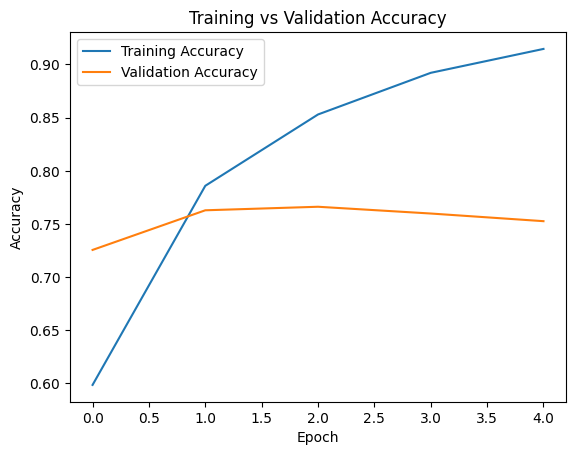

In [68]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()